In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sales = pd.read_csv(r"C:\Users\Rittush\Downloads\sales_data (4).csv")
customers = pd.read_csv(r"C:\Users\Rittush\Downloads\customer_churn.csv")

print(sales.head())
print(customers.head())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
  Customer_ID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0      C00001       6              64          1540        One year   
1      C00002      21             113          1753  Month-to-month   
2      C00003      27              31          1455        Two year   
3      C00004      53              29          7150  Month-to-month   
4      C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1

In [7]:
sales.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
sales.fillna(0, inplace=True)
customers.fillna("Unknown", inplace=True)

In [8]:
print("Sales Columns:")
print(sales.columns)

print("\nCustomer Columns:")
print(customers.columns)

Sales Columns:
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Customer Columns:
Index(['Customer_ID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')


In [14]:
merged_data = pd.merge(sales, customers, on="Customer_ID", how="outer")
print(merged_data.head())

  Date Product  Quantity  Price Customer_ID Region  Total_Sales  Tenure  \
0  NaN     NaN       NaN    NaN      C00001    NaN          NaN     6.0   
1  NaN     NaN       NaN    NaN      C00002    NaN          NaN    21.0   
2  NaN     NaN       NaN    NaN      C00003    NaN          NaN    27.0   
3  NaN     NaN       NaN    NaN      C00004    NaN          NaN    53.0   
4  NaN     NaN       NaN    NaN      C00005    NaN          NaN    16.0   

   MonthlyCharges  TotalCharges        Contract     PaymentMethod  \
0            64.0        1540.0        One year       Credit Card   
1           113.0        1753.0  Month-to-month  Electronic Check   
2            31.0        1455.0        Two year       Credit Card   
3            29.0        7150.0  Month-to-month  Electronic Check   
4           185.0        1023.0        One year  Electronic Check   

  PaperlessBilling  SeniorCitizen  Churn  
0               No            1.0    0.0  
1              Yes            1.0    0.0  
2    

In [16]:
customer_spending = merged_data.groupby("Customer_ID")["Total_Sales"].sum().reset_index()
customer_spending = customer_spending.sort_values(by="Total_Sales", ascending=False)
print(customer_spending.head())

    Customer_ID  Total_Sales
515     CUST016     373932.0
506     CUST007     363870.0
582     CUST083     350888.0
572     CUST073     349510.0
519     CUST020     333992.0


In [19]:
avg_order = merged_data.groupby("Customer_ID")["Total_Sales"].mean().reset_index()
avg_order.rename(columns={"Total_Sales": "Average_Order_Value"}, inplace=True)
print(avg_order.head())

  Customer_ID  Average_Order_Value
0      C00001                  NaN
1      C00002                  NaN
2      C00003                  NaN
3      C00004                  NaN
4      C00005                  NaN


In [23]:
purchase_frequency = merged_data.groupby("Customer_ID").count().reset_index()
purchase_frequency.rename(columns={"OrderID": "Total_Orders"}, inplace=True)

print(purchase_frequency.head())

  Customer_ID  Date  Product  Quantity  Price  Region  Total_Sales  Tenure  \
0      C00001     0        0         0      0       0            0       1   
1      C00002     0        0         0      0       0            0       1   
2      C00003     0        0         0      0       0            0       1   
3      C00004     0        0         0      0       0            0       1   
4      C00005     0        0         0      0       0            0       1   

   MonthlyCharges  TotalCharges  Contract  PaymentMethod  PaperlessBilling  \
0               1             1         1              1                 1   
1               1             1         1              1                 1   
2               1             1         1              1                 1   
3               1             1         1              1                 1   
4               1             1         1              1                 1   

   SeniorCitizen  Churn  
0              1      1  
1         

In [24]:
top_customers = customer_spending.head(10)
print("Top 10 Customers:")
print(top_customers)

Top 10 Customers:
    Customer_ID  Total_Sales
515     CUST016     373932.0
506     CUST007     363870.0
582     CUST083     350888.0
572     CUST073     349510.0
519     CUST020     333992.0
583     CUST084     324144.0
569     CUST070     318762.0
504     CUST005     318680.0
564     CUST065     312564.0
527     CUST028     304465.0


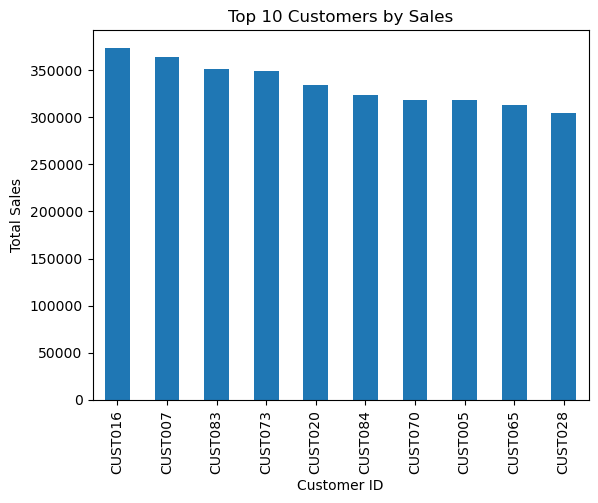

In [29]:
plt.figure()
top_customers.set_index("Customer_ID")["Total_Sales"].plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.show()

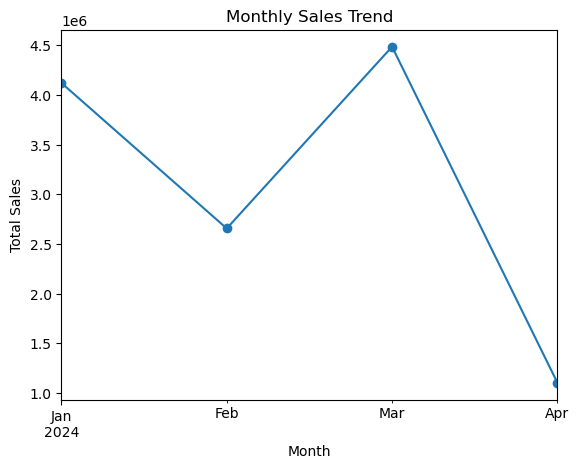

In [30]:
merged_data["Month"] = merged_data["Date"].dt.to_period("M")
monthly_sales = merged_data.groupby("Month")["Total_Sales"].sum()

plt.figure()
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.show()